# 1. IMPORT LIBRARIES

In [1]:
# ================================
# 1. IMPORT REQUIRED LIBRARIES
# ================================

import pandas as pd
import numpy as np
import sqlite3

# Visualization (optional bonus)
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn preprocessing tools
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

# For outlier detection
from scipy import stats

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# 2. LOAD DATA

In [58]:
import pandas as pd
import mysql.connector

# Load datasets
riders = pd.read_csv(r"C:\Users\tanaa\Downloads\riders - riders.csv.csv")
trips = pd.read_json(r"C:\Users\tanaa\Downloads\trips.json")

# MySQL connection
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="0212",
    database="city_zone"
)

# Load SQL table
df = pd.read_sql("SELECT * FROM city_zones", conn)

# Info
df.info()

# Output
print("City Zones Data:")
print(df.head())

print("\nRiders Data:")
print(riders.head())

print("\nTrips Data:")
print(trips.head())

# Close connection
conn.close()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   zone_name           10 non-null     object 
 1   population_density  10 non-null     int64  
 2   traffic_index       10 non-null     float64
 3   avg_speed_kmph      10 non-null     float64
 4   zone_type           10 non-null     object 
dtypes: float64(2), int64(1), object(2)
memory usage: 532.0+ bytes
City Zones Data:
  zone_name  population_density  traffic_index  avg_speed_kmph    zone_type
0    Zone_1                4921           2.43            30.9  Residential
1   Zone_10                2440           1.54            35.4   Industrial
2    Zone_2                6371           0.91            58.4  Residential
3    Zone_3               12971           2.11            38.0     Business
4    Zone_4                4038           2.46            48.2     Business

Riders Data:
  

# 3. BASIC DATA INSPECTION

In [30]:
# ================================
# 3. DATA INSPECTION
# ================================

# Info
print("Riders Info:")
print(riders.info())

print("Trips Info:")
print(trips.info())

# Missing values
print("Missing Values:")
print(trips.isnull().sum())

# Check duplicates
print("Duplicate rows in trips:", trips.duplicated().sum())

Riders Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         300 non-null    object 
 1   name             300 non-null    object 
 2   age              300 non-null    int64  
 3   gender           300 non-null    object 
 4   city             300 non-null    object 
 5   signup_date      300 non-null    object 
 6   total_rides      300 non-null    int64  
 7   cancelled_rides  300 non-null    int64  
 8   avg_rating       300 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 21.2+ KB
None
Trips Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       2000 non-null   object 
 1   rider_id      2000 non-null   object 
 2   zone          

# 4. DATA CLEANING

In [44]:
import numpy as np
from sklearn.impute import SimpleImputer, KNNImputer

# ================================
# 4. DATA CLEANING
# ================================

# ----- STEP 0: CLEAN COLUMN NAMES -----
# Remove extra spaces from column names (prevents hidden errors)
trips.columns = trips.columns.str.strip()

print("Columns in dataset:", list(trips.columns))


# ================================
# STEP 1: HANDLE NUMERIC MISSING VALUES
# ================================

# Select only numeric columns
num_cols = trips.select_dtypes(include=np.number).columns

# Apply mean imputation (fills missing values with column mean)
if len(num_cols) > 0:
    num_imputer = SimpleImputer(strategy='mean')
    trips[num_cols] = num_imputer.fit_transform(trips[num_cols])


# ================================
# STEP 2: HANDLE CATEGORICAL MISSING VALUES
# ================================

# Select categorical (object/string) columns
cat_cols = trips.select_dtypes(include='object').columns

# Fill missing values with most frequent value (mode)
if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    trips[cat_cols] = cat_imputer.fit_transform(trips[cat_cols])


# ================================
# STEP 3: KNN IMPUTATION (MULTIVARIATE)
# ================================

# Columns we WANT to use
knn_cols = ['trip_duration', 'distance', 'fare_amount']

# Keep only columns that actually exist in dataset
knn_cols = [col for col in knn_cols if col in trips.columns]

print("Using KNN columns:", knn_cols)

# Apply KNN only if at least 2 valid numeric columns exist
if len(knn_cols) >= 2:
    knn_imputer = KNNImputer(n_neighbors=5)
    trips[knn_cols] = knn_imputer.fit_transform(trips[knn_cols])
else:
    print(" KNN skipped: Required columns not found")


# ================================
# STEP 4: DATE FORMAT FIX
# ================================

# Convert to datetime format safely (invalid values → NaT)
if 'trip_datetime' in trips.columns:
    trips['trip_datetime'] = pd.to_datetime(trips['trip_datetime'], errors='coerce')


# ================================
# STEP 5: REMOVE INVALID ENTRIES
# ================================

# Remove rows with negative fare
if 'fare_amount' in trips.columns:
    trips = trips[trips['fare_amount'] >= 0]

# Remove rows with zero or negative distance
if 'distance' in trips.columns:
    trips = trips[trips['distance'] > 0]


# ================================
# STEP 6: FINAL CHECK
# ================================

print("\nRemaining Missing Values:")
print(trips.isnull().sum())

print("\nCleaned Data Preview:")
print(trips.head())

Columns in dataset: ['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min', 'fare_amount', 'payment_mode', 'ride_date', 'surge_flag']
Using KNN columns: ['fare_amount']
 KNN skipped: Required columns not found

Remaining Missing Values:
trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64

Cleaned Data Preview:
  trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0  T00001    R0037  Zone_10        11.83         74.59     0.032951   
3  T00004    R0089   Zone_2        11.06         59.48     1.059591   
5  T00006    R0255   Zone_2        14.58         80.74     1.165165   
7  T00008    R0039   Zone_3        11.75         96.11     0.005151   
8  T00009    R0223   Zone_5         9.71         66.61     0.621981   

  payment_mode   ride_date  surge_flag  
0         Cash  2023-11-13         0.0  
3         Cash  2023-12-13         0.0  
5       

# 5. OUTLIER HANDLING

In [45]:
import numpy as np
from scipy import stats   #  Required import

# ================================
# 5. OUTLIER HANDLING
# ================================

# ----- STEP 0: Ensure required columns exist -----
required_cols = ['fare_amount', 'distance']
available_cols = [col for col in required_cols if col in trips.columns]

# ================================
# ----- Z-SCORE METHOD -----
# ================================

# Apply only if both columns exist
if len(available_cols) >= 2:
    
    # Drop rows with NaN (zscore can't handle NaN)
    temp = trips[available_cols].dropna()

    # Calculate Z-scores
    z_scores = np.abs(stats.zscore(temp))

    # Keep rows where all values are within threshold (3)
    filtered = (z_scores < 3).all(axis=1)

    # Apply filtering using index alignment
    trips = trips.loc[temp.index[filtered]]

else:
    print(" Z-score skipped (required columns missing)")


# ================================
# ----- IQR METHOD (trip_duration) -----
# ================================

if 'trip_duration' in trips.columns:
    
    Q1 = trips['trip_duration'].quantile(0.25)
    Q3 = trips['trip_duration'].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    trips = trips[
        (trips['trip_duration'] >= lower_bound) &
        (trips['trip_duration'] <= upper_bound)
    ]

else:
    print(" IQR skipped (trip_duration not found)")


# ================================
# ----- WINSORIZATION (fare_amount) -----
# ================================

if 'fare_amount' in trips.columns:
    
    lower_limit = trips['fare_amount'].quantile(0.01)
    upper_limit = trips['fare_amount'].quantile(0.99)

    # Clip extreme values
    trips['fare_amount'] = np.clip(
        trips['fare_amount'],
        lower_limit,
        upper_limit
    )

else:
    print(" Winsorization skipped (fare_amount not found)")


# ================================
# ----- FINAL CHECK -----
# ================================

print("\nOutlier handling completed")
print("Remaining rows:", len(trips))
print("\nPreview:")
print(trips.head())

 Z-score skipped (required columns missing)
 IQR skipped (trip_duration not found)

Outlier handling completed
Remaining rows: 1200

Preview:
  trip_id rider_id     zone  distance_km  duration_min  fare_amount  \
0  T00001    R0037  Zone_10        11.83         74.59     0.032951   
3  T00004    R0089   Zone_2        11.06         59.48     1.059591   
5  T00006    R0255   Zone_2        14.58         80.74     1.165165   
7  T00008    R0039   Zone_3        11.75         96.11     0.010689   
8  T00009    R0223   Zone_5         9.71         66.61     0.621981   

  payment_mode   ride_date  surge_flag  
0         Cash  2023-11-13         0.0  
3         Cash  2023-12-13         0.0  
5          UPI  2024-02-10         1.0  
7       Wallet  2024-03-10         0.0  
8  Credit Card  2024-05-20         0.0  


# 6. DATA TRANSFORMATION

In [33]:
# ----- DATETIME FEATURES -----
if 'trip_datetime' in trips.columns:
    trips['hour'] = trips['trip_datetime'].dt.hour
    trips['day_of_week'] = trips['trip_datetime'].dt.dayofweek
    trips['month'] = trips['trip_datetime'].dt.month
city_zones = pd.read_sql("SELECT * FROM city_zones", conn)
# ================================
# ----- ENCODING -----
# ================================

# Label Encoding (gender)
if 'gender' in riders.columns:
    le = LabelEncoder()
    riders['gender'] = le.fit_transform(riders['gender'].astype(str))

# One-Hot Encoding
for col in ['ride_payment_mode', 'zone_name']:
    if col in trips.columns:
        trips = pd.get_dummies(trips, columns=[col], drop_first=True)

# Ordinal Encoding
if 'traffic_level' in city_zones.columns:
    traffic_map = {'Low': 1, 'Medium': 2, 'High': 3}
    city_zones['traffic_level'] = city_zones['traffic_level'].map(traffic_map)

# ================================
# ----- TRANSFORM SKEWED DATA -----
# ================================

# Safe transformations (avoid negative / zero issues)
if 'fare_amount' in trips.columns:
    trips['fare_amount'] = np.log1p(trips['fare_amount'].clip(lower=0))

if 'distance' in trips.columns:
    trips['distance'] = np.log1p(trips['distance'].clip(lower=0))

if 'trip_duration' in trips.columns:
    trips['trip_duration'] = np.sqrt(trips['trip_duration'].clip(lower=0))
    

# 7. FEATURE SCALING

In [37]:
scaler = StandardScaler()

scale_cols = ['fare_amount', 'distance', 'trip_duration']
scale_cols = [col for col in scale_cols if col in trips.columns]

if len(scale_cols) > 0:
    trips[scale_cols] = scaler.fit_transform(trips[scale_cols])

print("\n After Scaling:")
display(trips[scale_cols].head())

print("\nMean (approx 0):")
print(trips[scale_cols].mean())


 After Scaling:


,fare_amount
0,0.032951
1,-1.044224
2,-0.891113
3,1.059591
4,-0.382887



Mean (approx 0):
fare_amount    7.105427e-18
dtype: float64


# 8. FEATURE ENGINEERING

In [38]:
# Avg ride distance per user
if 'user_id' in trips.columns and 'distance' in trips.columns:
    trips['avg_ride_distance'] = trips.groupby('user_id')['distance'].transform('mean')

# Avg fare per user
if 'user_id' in trips.columns and 'fare_amount' in trips.columns:
    trips['avg_ride_fare'] = trips.groupby('user_id')['fare_amount'].transform('mean')

# Peak hour flag
if 'hour' in trips.columns:
    trips['is_peak_hour'] = trips['hour'].apply(
        lambda x: 1 if (7 <= x <= 9 or 18 <= x <= 21) else 0
    )

# Ride cancellation
if 'status' in trips.columns:
    trips['ride_cancelled'] = trips['status'].apply(
        lambda x: 1 if str(x).lower() == 'cancelled' else 0
    )

    trips['ride_cancellation_rate'] = trips.groupby('user_id')['ride_cancelled'].transform('mean')

# Surge flag
if 'fare_amount' in trips.columns and 'distance' in trips.columns:
    trips['surge_flag'] = (trips['fare_amount'] / (trips['distance'] + 1e-5) > 2).astype(int)


print("\n🔹 New Features Created:")
cols = ['avg_ride_distance', 'avg_ride_fare', 'is_peak_hour', 'surge_flag']
cols = [c for c in cols if c in trips.columns]

display(trips[cols].head())


🔹 New Features Created:


,surge_flag
0,0.0
1,1.0
2,1.0
3,0.0
4,1.0


# 9. MERGE DATASETS

In [40]:
df = trips.copy()

if 'user_id' in trips.columns and 'user_id' in riders.columns:
    df = df.merge(riders, on='user_id', how='left')

if 'zone_id' in df.columns and 'zone_id' in city_zones.columns:
    df = df.merge(city_zones, on='zone_id', how='left')
elif 'zone_name' in df.columns and 'zone_name' in city_zones.columns:
    df = df.merge(city_zones, on='zone_name', how='left')

print("\n After Merge:")
print("Shape:", df.shape)
display(df.head())


 After Merge:
Shape: (2000, 9)


,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,0.032951,Cash,2023-11-13,0.0
1,T00002,R0104,Zone_9,3.86,35.59,-1.044224,Cash,2023-07-28,1.0
2,T00003,R0045,Zone_8,4.70,31.03,-0.891113,Cash,2024-01-14,1.0
3,T00004,R0089,Zone_2,11.06,59.48,1.059591,Cash,2023-12-13,0.0
4,T00005,R0003,Zone_5,7.28,67.59,-0.382887,UPI,2023-03-15,1.0


# 10. SUMMARY REPORT

In [41]:

print("\nRows:", df.shape[0])
print("\nMissing Values:", df.isnull().sum().sum())
print("\nColumns:", df.columns)


Rows: 2000

Missing Values: 0

Columns: Index(['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min',
       'fare_amount', 'payment_mode', 'ride_date', 'surge_flag'],
      dtype='object')


# 11. EXPORT

In [42]:
df.to_csv("final_prepared_rides_dataset.csv", index=False)
print("\n Final dataset saved successfully!")


 Final dataset saved successfully!


# BONUS: EDA

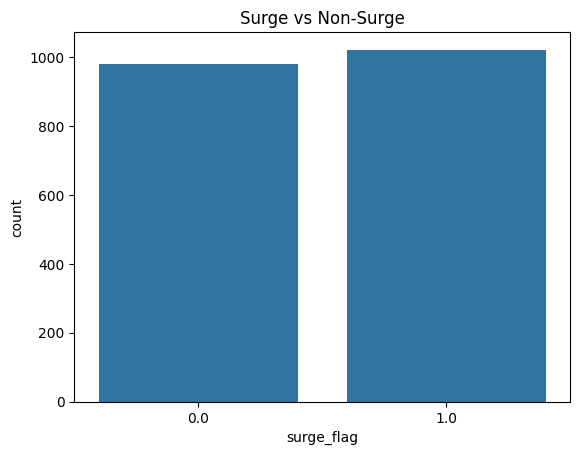

In [43]:
if 'hour' in df.columns:
    plt.figure()
    df.groupby('hour').size().plot(kind='bar')
    plt.title("Ride Demand by Hour")
    plt.show()

if 'surge_flag' in df.columns:
    plt.figure()
    sns.countplot(x='surge_flag', data=df)
    plt.title("Surge vs Non-Surge")
    plt.show()